In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.collections import LineCollection
from scipy.signal import coherence
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d import Axes3D

import sys
sys.path.insert(0, r'C:\Users\jeanv\OneDrive - Delft University of Technology\Uitwisseling - TUDelft\Courses\MEP\Programming\extra')



from gradientAnalysis.functions import find_plateaus, analyze_drift, savgolCompilator, rangeSelector, coherenceData, powerlaw, powerlawFitter, singleWelch
from gradientAnalysis.plots import channelPlotter, coherencePlotter, coherenceFitPlotter, experimentPlotter, plot_thermal_results, savgolCalcPlotter, plotOverviewDashboard


Path = r"C:\Users\jeanv\OneDrive - Delft University of Technology\Uitwisseling - TUDelft\Courses\MEP\Experiments\corrosion"

# Loading data from the text files

dataRun = np.loadtxt(Path + r"\static24h650deg.txt", delimiter="\t")




time = dataRun[:, 0]
CH0 = dataRun[:, 1]
CH1 = dataRun[:, 2]
CH2 = dataRun[:, 3]
CH3 = dataRun[:, 4]

print(time[-1])

94914.688


C:\Users\jeanv\OneDrive - Delft University of Technology\Uitwisseling - TUDelft\Courses\MEP\Programming\extra\gradientAnalysis\plots.py:165: SyntaxWarning: invalid escape sequence '\p'
  label='Measured Exponent $b \pm \sigma$', markersize=0.5)
C:\Users\jeanv\OneDrive - Delft University of Technology\Uitwisseling - TUDelft\Courses\MEP\Programming\extra\gradientAnalysis\plots.py:193: SyntaxWarning: invalid escape sequence '\p'
  label='Coherence $b \pm \sigma$')


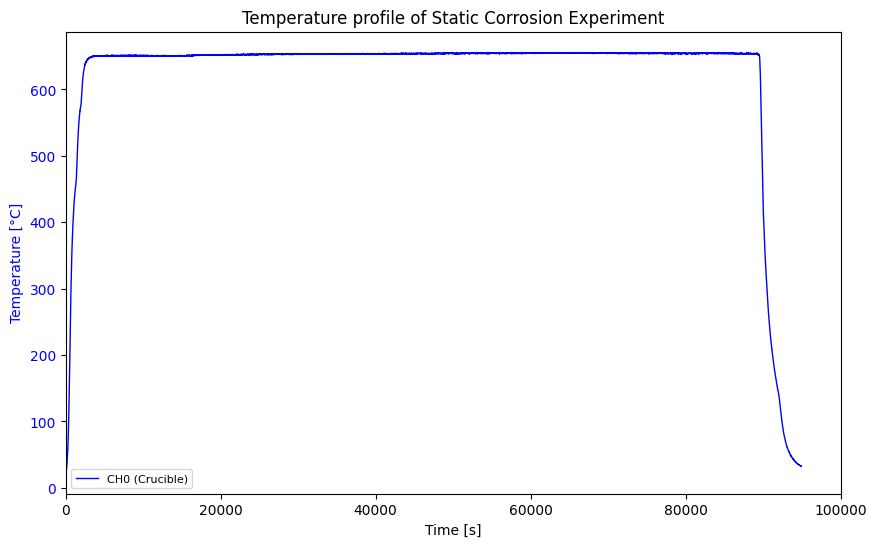

In [2]:
channelPlotter([CH0], [time], r"Temperature profile of Static Corrosion Experiment", color=["blue"], rangex=[0, 100000], labels=["CH0 (Crucible)", "Derivative"], linestyles="-", twin = False, extratwin = False, epsilon=None)

In [3]:
time_r, CH0_r = rangeSelector(CH0, time, [0, 100000])
mean_temp = np.mean(CH0_r)
std_dev = np.std(CH0_r)

print(f"Mean temperature: {mean_temp:.2f} +- {std_dev:.2f}")


Mean temperature: 619.21 +- 127.02


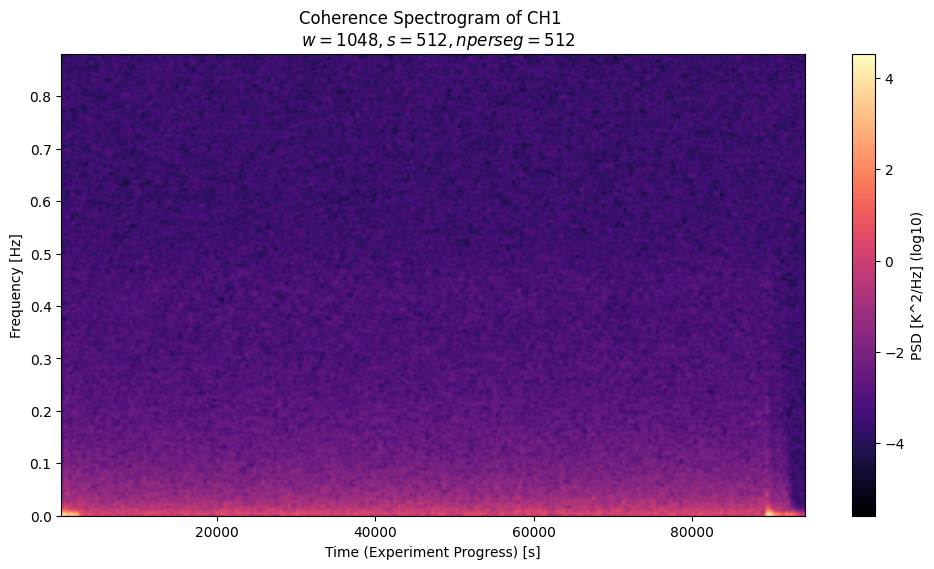

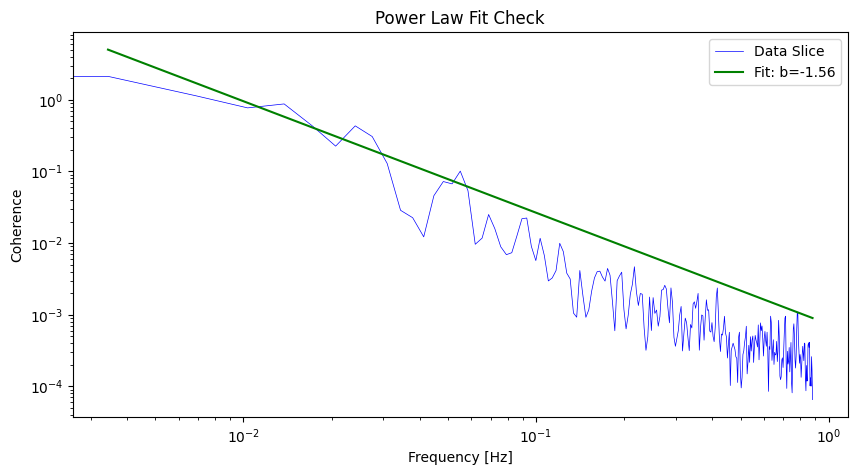

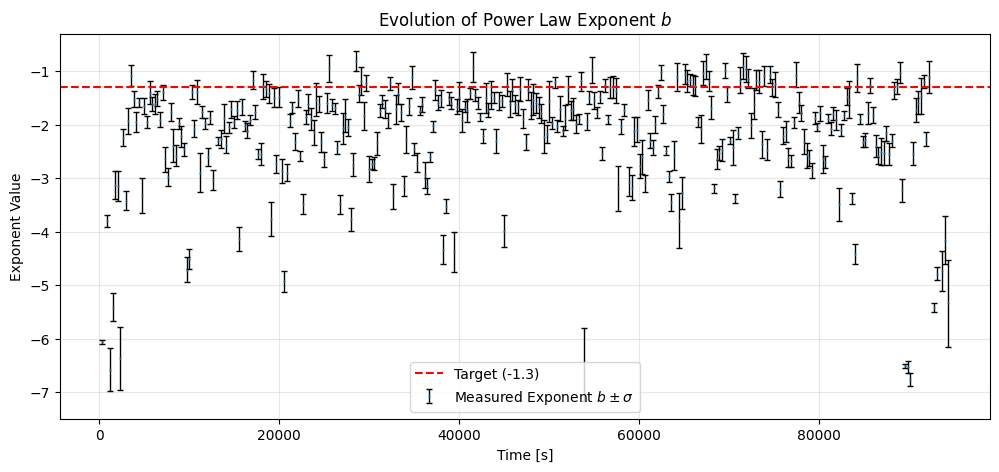

In [10]:
window_size, step_size, nperseg =   1048, 512, 512
win_t, f, Z, Z_log, Z_ax, a_arr, b_arr, b_errors  = singleWelch(CH0_r, time_r, window_size=window_size, step_size=step_size, nperseg=nperseg, logaxis=True, freq_range=[0.01,0.1], dtrend=True)
coherencePlotter(win_t, f, Z_log, Z_ax, window_size, step_size, nperseg, runID="CH1", cmap="magma")

coherenceFitPlotter(f, Z[:, 150], a_arr[150], b_arr[150], windows_time=win_t, b_fits_array=b_arr, b_errors=b_errors)
